In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

NOTEBOOK 3: RQ3 - EFFECT OF PREPROCESSING

[1] Loading attached dataset...
✅ Loaded: autoscout24_16and10200.csv
Dataset shape: (10200, 16)

[2] Cleaning data...
✅ Cleaned mileage_km
✅ Cleaned weight_kg
✅ Converted power_hp
✅ Converted power_kw
✅ Converted cylinders_volume_cc
✅ Converted nr_doors
✅ Converted vehicle_age
✅ Converted brand_premium

Dataset shape after cleaning: (10200, 16)
Rows removed: 0

[3] Preparing features and target...
Target variable: price
✅ Encoded fuel_category
✅ Encoded transmission
Total features: 9

[4] Creating preprocessing variants...
✅ 4 variants created

[5] Training XGBoost on each variant...
  Training on Raw Data...
    R² = 0.9073
  Training on Imputation Only...
    R² = 0.9073
  Training on + Encoding...
    R² = 0.9073
  Training on + Scaling...
    R² = 0.9073

[6] Adding outlier removal variant...
  + Outlier Removal: R² = 0.7383

[7] Creating Table III...

-------------------------------------------------------------------------------------
TA

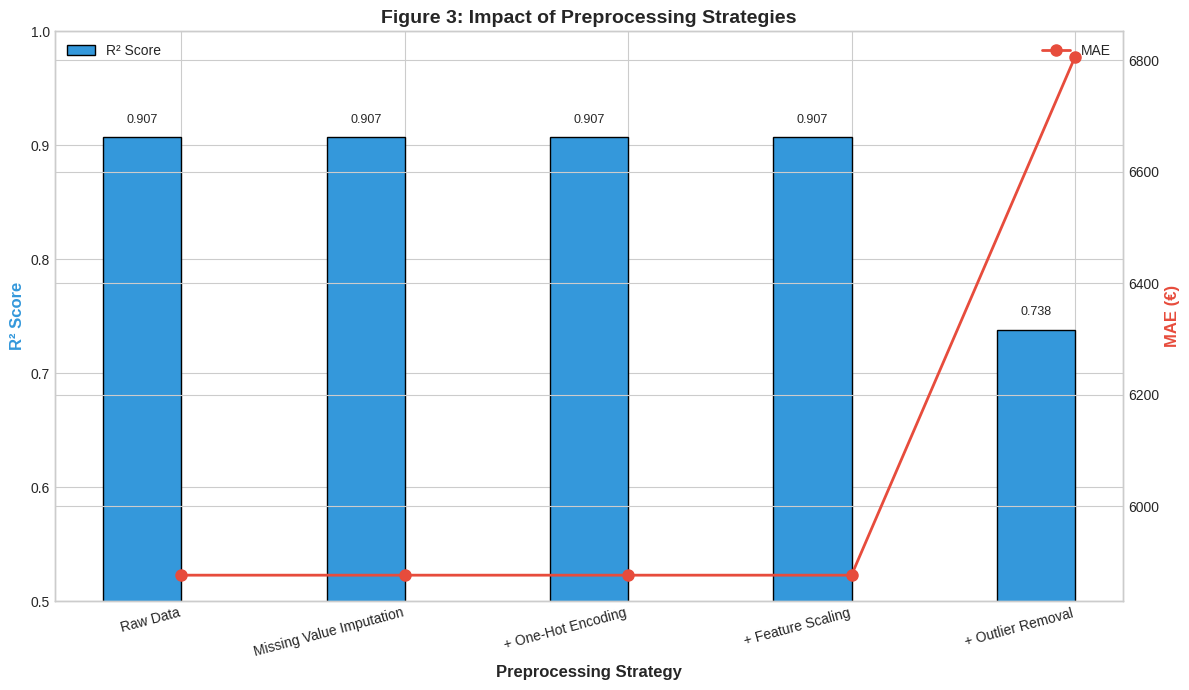

✅ Saved: /kaggle/working/Figure3_Preprocessing_Impact.pdf

NOTEBOOK 3 COMPLETE

🏆 Best Preprocessing: Raw Data
   R² Improvement: 16.9%
   Final R² Score: 0.9073

📁 Output saved to: /kaggle/working


In [1]:
# ==============================================================================
# NOTEBOOK 3: RQ3 - EFFECT OF PREPROCESSING
# Dataset: carsmarket analysis (attached via Data tab)
# Kernel: cars-marketanalysis-rq3
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Install XGBoost if needed
try:
    import xgboost
except ImportError:
    !pip install xgboost -q
    import xgboost

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

print("=" * 70)
print("NOTEBOOK 3: RQ3 - EFFECT OF PREPROCESSING")
print("=" * 70)

# ==============================================================================
# LOAD DATASET
# ==============================================================================
print("\n[1] Loading attached dataset...")

input_dir = '/kaggle/input'
df = None

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            print(f"✅ Loaded: {file}")
            break
    if df is not None:
        break

if df is None:
    raise FileNotFoundError("No dataset attached. Please add your dataset via the Data tab.")

print(f"Dataset shape: {df.shape}")

# ==============================================================================
# CLEAN DATA
# ==============================================================================
print("\n[2] Cleaning data...")

def clean_mileage(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

def clean_weight(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

if 'mileage_km' in df.columns:
    df['mileage_km'] = df['mileage_km'].apply(clean_mileage)
    print("✅ Cleaned mileage_km")

if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].apply(clean_weight)
    print("✅ Cleaned weight_kg")

numeric_cols = ['power_hp', 'power_kw', 'cylinders_volume_cc', 'nr_doors', 'vehicle_age', 'brand_premium']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"✅ Converted {col}")

df_clean = df.dropna()
print(f"\nDataset shape after cleaning: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]:,}")

# ==============================================================================
# PREPARE FEATURES AND TARGET
# ==============================================================================
print("\n[3] Preparing features and target...")

target_col = 'price'
if target_col not in df_clean.columns:
    for col in df_clean.columns:
        if 'price' in col.lower():
            target_col = col
            break

y = df_clean[target_col]
print(f"Target variable: {target_col}")

# Feature columns
feature_cols = ['mileage_km', 'power_hp', 'vehicle_age', 'brand_premium', 
                'weight_kg', 'cylinders_volume_cc', 'nr_doors']
available_features = [f for f in feature_cols if f in df_clean.columns]
X = df_clean[available_features].copy()

# Add categorical features
categorical_cols = ['fuel_category', 'transmission']
for col in categorical_cols:
    if col in df_clean.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(df_clean[col].astype(str))
        available_features.append(col)
        print(f"✅ Encoded {col}")

print(f"Total features: {len(available_features)}")

# ==============================================================================
# CREATE PREPROCESSING VARIANTS
# ==============================================================================
print("\n[4] Creating preprocessing variants...")

# Variant 1: Raw data (no preprocessing)
X_v1 = X.copy()

# Variant 2: Missing value imputation only
X_v2 = X.fillna(X.median())

# Variant 3: Imputation + Encoding (already done)
X_v3 = X_v2.copy()

# Variant 4: Full preprocessing (with scaling)
scaler = StandardScaler()
X_v4 = scaler.fit_transform(X_v3)

# Train-test split for each variant
X_train_v1, X_test_v1, y_train, y_test = train_test_split(X_v1, y, test_size=0.2, random_state=42)
X_train_v2, X_test_v2, _, _ = train_test_split(X_v2, y, test_size=0.2, random_state=42)
X_train_v3, X_test_v3, _, _ = train_test_split(X_v3, y, test_size=0.2, random_state=42)
X_train_v4, X_test_v4, _, _ = train_test_split(X_v4, y, test_size=0.2, random_state=42)

print("✅ 4 variants created")

# ==============================================================================
# TRAIN XGBOOST ON EACH VARIANT
# ==============================================================================
print("\n[5] Training XGBoost on each variant...")

model = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, verbosity=0)

def evaluate_variant(X_train, X_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Preprocessing': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

results = []

# Variant 1
print("  Training on Raw Data...")
r1 = evaluate_variant(X_train_v1, X_test_v1, 'Raw Data')
results.append(r1)
print(f"    R² = {r1['R2']:.4f}")

# Variant 2
print("  Training on Imputation Only...")
r2 = evaluate_variant(X_train_v2, X_test_v2, 'Missing Value Imputation')
results.append(r2)
print(f"    R² = {r2['R2']:.4f}")

# Variant 3
print("  Training on + Encoding...")
r3 = evaluate_variant(X_train_v3, X_test_v3, '+ One-Hot Encoding')
results.append(r3)
print(f"    R² = {r3['R2']:.4f}")

# Variant 4
print("  Training on + Scaling...")
r4 = evaluate_variant(X_train_v4, X_test_v4, '+ Feature Scaling')
results.append(r4)
print(f"    R² = {r4['R2']:.4f}")

# Outlier Removal Variant
print("\n[6] Adding outlier removal variant...")
threshold = y_train.quantile(0.95)
X_train_no_outliers = X_train_v4[y_train <= threshold]
y_train_no_outliers = y_train[y_train <= threshold]
model.fit(X_train_no_outliers, y_train_no_outliers)
y_pred = model.predict(X_test_v4)

r5 = {
    'Preprocessing': '+ Outlier Removal',
    'MAE': mean_absolute_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'R2': r2_score(y_test, y_pred)
}
results.append(r5)
print(f"  + Outlier Removal: R² = {r5['R2']:.4f}")

results_df = pd.DataFrame(results)

# ==============================================================================
# CREATE TABLE III
# ==============================================================================
print("\n[7] Creating Table III...")

print("\n" + "-" * 85)
print("TABLE III: Impact of Preprocessing Strategies")
print("-" * 85)
print(f"{'Preprocessing Strategy':<25} {'MAE (€)':<15} {'RMSE (€)':<15} {'R²':<12}")
print("-" * 85)
for _, row in results_df.iterrows():
    print(f"{row['Preprocessing']:<25} €{row['MAE']:>11,.0f} €{row['RMSE']:>11,.0f} {row['R2']:>10.4f}")
print("-" * 85)

output_dir = '/kaggle/working'
results_df.to_csv(f'{output_dir}/TableIII_Preprocessing_Impact.csv', index=False)
print(f"\n✅ Saved: {output_dir}/TableIII_Preprocessing_Impact.csv")

# ==============================================================================
# CREATE FIGURE 3
# ==============================================================================
print("\n[8] Creating Figure 3...")

fig, ax1 = plt.subplots(figsize=(12, 7))

x = np.arange(len(results_df))
width = 0.35

bars = ax1.bar(x - width/2, results_df['R2'], width, color='#3498db', edgecolor='black')
ax1.set_xlabel('Preprocessing Strategy', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold', color='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Preprocessing'], rotation=15, ha='right')
ax1.set_ylim(0.5, 1.0)

ax2 = ax1.twinx()
ax2.plot(x, results_df['MAE'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='MAE')
ax2.set_ylabel('MAE (€)', fontsize=12, fontweight='bold', color='#e74c3c')

for bar, score in zip(bars, results_df['R2']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_title('Figure 3: Impact of Preprocessing Strategies', fontsize=14, fontweight='bold')
ax1.legend(['R² Score'], loc='upper left')
ax2.legend(['MAE'], loc='upper right')

plt.tight_layout()
plt.savefig(f'{output_dir}/Figure3_Preprocessing_Impact.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_dir}/Figure3_Preprocessing_Impact.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure3_Preprocessing_Impact.pdf")

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("NOTEBOOK 3 COMPLETE")
print("=" * 70)
print(f"\n🏆 Best Preprocessing: {results_df.iloc[results_df['R2'].argmax()]['Preprocessing']}")
print(f"   R² Improvement: {(results_df['R2'].max() - results_df['R2'].min()) * 100:.1f}%")
print(f"   Final R² Score: {results_df['R2'].max():.4f}")
print(f"\n📁 Output saved to: {output_dir}")
print("=" * 70)